# Data Analysis

## Data Cleaning

### Setup

First we import the necessary libraries:

In [609]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

Now we turn the crashes.csv files into a dataframe:

In [558]:
crashes_raw = pd.read_csv('data/crashes.csv')
crashes_raw.sample(10)

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
264,IT1:41_983(1.0),A,1020,KILLINJ,F,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59557,IT1:41_983(1.0),A,44013,KILLINJ,M,2022,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28783,IT1:41_983(1.0),A,16198,KILLINJ,F,2024,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79820,IT1:41_983(1.0),A,66087,ROADACC,9,2021,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82096,IT1:41_983(1.0),A,69048,KILLINJ,M,2020,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1585,IT1:41_983(1.0),A,1112,ROADACC,9,2020,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75928,IT1:41_983(1.0),A,64092,ROADACC,9,2023,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102813,IT1:41_983(1.0),A,93032,KILLINJ,F,2020,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50651,IT1:41_983(1.0),A,30027,KILLINJ,M,2020,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87056,IT1:41_983(1.0),A,75057,KILLINJ,M,2020,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Then we transform also the SITUAS .csv files into a dataframe:

In [559]:
cities_raw = pd.DataFrame()

for i in range(5):
    df_tmp = pd.read_csv('data/situas_202'+str(i)+'.csv',sep=';')
    cities_raw = pd.concat([cities_raw,df_tmp])
    print('situas_202'+str(i)+'.csv concatenated')

cities_raw.index = pd.RangeIndex(len(cities_raw))

situas_2020.csv concatenated
situas_2021.csv concatenated
situas_2022.csv concatenated
situas_2023.csv concatenated
situas_2024.csv concatenated


In [560]:
cities_raw.sample(10)

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
31514,5,20,111,111,111011,111011,Castiadas,NaN,SU,0,0,1661,2021,"103,9298",2023,1707,2023
11429,2,6,30,30,30035,30035,Enemonzo,NaN,UD,0,0,1280,2021,"23,7602",2021,1280,2021
37691,4,17,76,76,76021,76021,Castelgrande,NaN,PZ,0,0,825,2021,"34,8984",2024,800,2024
3799,2,8,36,36,36010,36010,Concordia sulla Secchia,NaN,MO,0,0,8968,2011,"40,9448",2020,8162,2020
38562,5,20,90,90,90043,90043,Muros,NaN,SS,0,0,830,2021,"11,2256",2024,821,2024
26949,2,5,26,26,26041,26041,Meduna di Livenza,NaN,TV,0,0,2947,2021,"15,3791",2023,2984,2023
32551,1,1,6,6,6101,6101,Monleale,NaN,AL,0,0,553,2021,"9,6176",2024,561,2024
17054,1,7,10,210,10006,10006,Busalla,NaN,GE,0,0,5168,2021,"17,1058",2022,5104,2022
25642,1,3,16,16,16102,16102,Fonteno,NaN,BG,0,0,567,2021,"10,9291",2023,565,2023
30201,4,18,80,280,80066,80066,Roccaforte del Greco,NaN,RC,0,0,367,2021,"43,8564",2023,317,2023


### Data cleaning

For safety reasons, we will implement data cleaning on copies of the original dataframes.

In [561]:
crashes = crashes_raw.copy()
cities = cities_raw.copy()

We start from the crashes dataframe:

In [562]:
crashes.info()

<class 'pandas.DataFrame'>
RangeIndex: 113856 entries, 0 to 113855
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          113856 non-null  str    
 1   FREQ              113856 non-null  str    
 2   REF_AREA          113856 non-null  int64  
 3   DATA_TYPE         113856 non-null  str    
 4   RESULT            113856 non-null  str    
 5   TIME_PERIOD       113856 non-null  int64  
 6   OBS_VALUE         113856 non-null  int64  
 7   OBS_STATUS        0 non-null       float64
 8   NOTE_DS           0 non-null       float64
 9   NOTE_REF_AREA     0 non-null       float64
 10  NOTE_DATA_TYPE    0 non-null       float64
 11  NOTE_RESULT       0 non-null       float64
 12  NOTE_TIME_PERIOD  0 non-null       float64
 13  BASE_PER          0 non-null       float64
 14  UNIT_MEAS         0 non-null       float64
 15  UNIT_MULT         0 non-null       float64
dtypes: float64(9), int64(3), str(4)

we see that all columns from 7 to 15 are completely nan. We can therefore drop them without losing any information.

In [563]:
crashes = crashes.dropna(axis=1,how='all')
crashes.head()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2020,4
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2021,2
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2022,5
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2023,6
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2024,5


We can also drop the columns "DATAFLOW" and "FREQ". The first one indicates the dataset, while the second one simply states that data has been collected yearly. Both this columns are made of identical entries for every row.

In [564]:
crashes['DATAFLOW'].unique()

<StringArray>
['IT1:41_983(1.0)']
Length: 1, dtype: str

In [565]:
crashes['FREQ'].unique()

<StringArray>
['A']
Length: 1, dtype: str

In [566]:
crashes.drop(columns=['DATAFLOW','FREQ'],inplace=True)
crashes.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
0,1001,KILLINJ,F,2020,4
1,1001,KILLINJ,F,2021,2
2,1001,KILLINJ,F,2022,5
3,1001,KILLINJ,F,2023,6
4,1001,KILLINJ,F,2024,5


Now if we inspect the entries corrisponding to a given REF_AREA (i.e. a city) and year:

In [567]:
crashes[(crashes['REF_AREA']==1001) & (crashes['TIME_PERIOD']==2020)]

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
0,1001,KILLINJ,F,2020,4
5,1001,KILLINJ,M,2020,0
10,1001,ROADACC,9,2020,4


We see that for each city and year there are 3 entries, labeled by DATA_TYPE and RESULT. In particular, DATA_TYPE discriminates between the crashes count (ROADACC) or the number of killed/injured (KILLINJ). To further distinguish between these last two categories, we make use of the column RESULT, labeling the number of killed (M) or injured (F) - while it is 9 for ROADACC since it doesn't carry any meaning. Thus, the OBS_VALUE entry can indicate at the same time the number of crashes, of victims or injured people.

This method might be more comfortable in data aquisition, but not in data visualization, so we shall reduce all this information into one single row for each couple (city,year). We start by merging DATA_TYPE and RESULT into a single column. This can be done by simply modifying the DATA_TYPE column accordingly:

In [568]:
crashes.loc[crashes['RESULT']=='M','DATA_TYPE'] = 'KILLED'
crashes.loc[crashes['RESULT']=='F','DATA_TYPE'] = 'INJURED'
crashes[(crashes['REF_AREA']==1001) & (crashes['TIME_PERIOD']==2020)]

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
0,1001,INJURED,F,2020,4
5,1001,KILLED,M,2020,0
10,1001,ROADACC,9,2020,4


Now all information is encoded in DATA_TYPE, so we can drop the RESULT column and pivot our table.

In [569]:
crashes.drop(columns='RESULT',inplace=True)

In [570]:
crashes = crashes.pivot(index=['REF_AREA','TIME_PERIOD'],columns='DATA_TYPE',values='OBS_VALUE')
crashes.head(10)

DATA_TYPE             INJURED  KILLED  ROADACC
REF_AREA TIME_PERIOD                          
1001     2020               4       0        4
         2021               2       0        2
         2022               5       0        3
         2023               6       1        3
         2024               5       0        2
1002     2020              14       0        8
         2021               9       0        6
         2022               5       0        4
         2023              10       1        7
         2024               9       0        5

Now we just have to make this table a little nicer with respect to the columns' names.

In [571]:
crashes.columns.name = None
crashes.reset_index(inplace=True)
crashes.rename(columns={'TIME_PERIOD':'Year',
                        'REF_AREA':'CITY_CODE'},inplace=True)
crashes.head(10)


,CITY_CODE,Year,INJURED,KILLED,ROADACC
0,1001,2020,4,0,4
1,1001,2021,2,0,2
2,1001,2022,5,0,3
3,1001,2023,6,1,3
4,1001,2024,5,0,2
5,1002,2020,14,0,8
6,1002,2021,9,0,6
7,1002,2022,5,0,4
8,1002,2023,10,1,7
9,1002,2024,9,0,5


We can now be (momentarily) satisfied with crashes. Inspecting the cities dataframe:

In [572]:
cities.info()

<class 'pandas.DataFrame'>
RangeIndex: 39507 entries, 0 to 39506
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Codice Ripartizione geografica  39507 non-null  int64
 1   Codice Regione                  39507 non-null  int64
 2   Codice Provincia (Storico)      39507 non-null  int64
 3   Codice Provincia/Uts            39507 non-null  int64
 4   Codice Comune (alfanumerico)    39507 non-null  int64
 5   Codice Comune (numerico)        39507 non-null  int64
 6   Comune                          39502 non-null  str  
 7   Comune (dizione straniera)      620 non-null    str  
 8   Sigla automobilistica           39047 non-null  str  
 9   Capoluogo di Provincia/Uts      39507 non-null  int64
 10  Capoluogo di Regione            39507 non-null  int64
 11  Popolazione legale              39507 non-null  int64
 12  Anno Censimento                 39507 non-null  int64
 13  Superficie (

Note that there are 5 nan entries in section "Comune". We ignore nans in "Comune (dizione straniera)" because they simply label cities that have only Italian name - in fact most of that column is made of nans.

In [573]:
cities[cities['Comune'].isna()]

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
164,1,1,1,201,1168,1168,NaN,NaN,TO,0,0,7998,2011,"24,6422",2020,7849,2020
8067,1,1,1,201,1168,1168,NaN,NaN,TO,0,0,7830,2021,"24,6422",2021,7830,2021
15971,1,1,1,201,1168,1168,NaN,NaN,TO,0,0,7830,2021,"24,6422",2022,7790,2022
23875,1,1,1,201,1168,1168,NaN,NaN,TO,0,0,7830,2021,"24,6422",2023,7688,2023
31775,1,1,1,201,1168,1168,NaN,NaN,TO,0,0,7830,2021,"24,6422",2024,7662,2024


Observing these entries we can see that there is one for each year. It is likely to be data referring to the same city, the name of which has been lost somehow. Inspecting the crashes dataframe by means of the city code leads us to the same conclusion:

In [574]:
crashes.loc[crashes['CITY_CODE']==1168]

,CITY_CODE,Year,INJURED,KILLED,ROADACC
776,1168,2020,11,0,8
777,1168,2021,11,0,9
778,1168,2022,10,0,7
779,1168,2023,9,0,7
780,1168,2024,7,0,5


By searching directly in the database, we find out that this code corresponds to the town of None (TO), in Piemonte. This is coherent with all other entries in the dataset corresponding to the same code. It might be possible that, while reading the .csv, None has been interpreted by Python as NaN! However, we can easily fix this issue.

In [575]:
cities.loc[cities['Codice Comune (numerico)']==1168,'Comune'] = 'None'
cities.info()

<class 'pandas.DataFrame'>
RangeIndex: 39507 entries, 0 to 39506
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Codice Ripartizione geografica  39507 non-null  int64
 1   Codice Regione                  39507 non-null  int64
 2   Codice Provincia (Storico)      39507 non-null  int64
 3   Codice Provincia/Uts            39507 non-null  int64
 4   Codice Comune (alfanumerico)    39507 non-null  int64
 5   Codice Comune (numerico)        39507 non-null  int64
 6   Comune                          39507 non-null  str  
 7   Comune (dizione straniera)      620 non-null    str  
 8   Sigla automobilistica           39047 non-null  str  
 9   Capoluogo di Provincia/Uts      39507 non-null  int64
 10  Capoluogo di Regione            39507 non-null  int64
 11  Popolazione legale              39507 non-null  int64
 12  Anno Censimento                 39507 non-null  int64
 13  Superficie (

### Joining crashes and cities

Now we are ready to join the two dataframes in order to get the full picture. Before doing that, however, we can check if there are some values in CITY_CODE that don't have a correspondence in cities. This can be done with:

In [576]:
extra_code = set(crashes[~crashes['CITY_CODE'].isin(cities['Codice Comune (numerico)'])]['CITY_CODE'])
extra_code

{41032}

An online research shows that the code 41032 corresponds to the town of Monteciccardo, that has been incorporated into Pesaro since July the 1st 2020. This poses no problems for our analysis since there have been no crashes in the first 6 months of 2020:

In [577]:
crashes.loc[crashes['CITY_CODE']==41032]

,CITY_CODE,Year,INJURED,KILLED,ROADACC
19189,41032,2020,0,0,0


Therefore we can simply expunge this row without causing any troubles.

In [578]:
crashes = crashes[crashes['CITY_CODE']!=41032]

Now we can perform the join:

In [579]:
crashes_cities = crashes.merge(cities,how='left',left_on=['CITY_CODE','Year'],right_on=['Codice Comune (numerico)','Anno (Superficie)'])
crashes_cities = crashes_cities[['Year','Codice Ripartizione geografica','Codice Regione','Codice Provincia (Storico)',
                                 'CITY_CODE','Comune','Capoluogo di Provincia/Uts','Capoluogo di Regione',
                                 'Superficie (Kmq)','Popolazione residente','ROADACC','KILLED','INJURED']]
crashes_cities.info()

<class 'pandas.DataFrame'>
RangeIndex: 37951 entries, 0 to 37950
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            37951 non-null  int64  
 1   Codice Ripartizione geografica  37950 non-null  float64
 2   Codice Regione                  37950 non-null  float64
 3   Codice Provincia (Storico)      37950 non-null  float64
 4   CITY_CODE                       37951 non-null  int64  
 5   Comune                          37950 non-null  str    
 6   Capoluogo di Provincia/Uts      37950 non-null  float64
 7   Capoluogo di Regione            37950 non-null  float64
 8   Superficie (Kmq)                37950 non-null  str    
 9   Popolazione residente           37950 non-null  float64
 10  ROADACC                         37951 non-null  int64  
 11  KILLED                          37951 non-null  int64  
 12  INJURED                         37951 non-n

However note that all columns from cities have one NaN value. Let's investigate:

In [580]:
crashes_cities[crashes_cities['Codice Regione'].isna()]

,Year,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),CITY_CODE,Comune,Capoluogo di Provincia/Uts,Capoluogo di Regione,Superficie (Kmq),Popolazione residente,ROADACC,KILLED,INJURED
10868,2023,NaN,NaN,NaN,18002,NaN,NaN,NaN,NaN,NaN,0,0,0


If we search for the code 18002 in cities, we see that:

In [581]:
cities[cities['Codice Comune (numerico)']==18002]

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
2286,1,3,18,18,18002,18002,Albaredo Arnaboldi,NaN,PV,0,0,225,2011,"8,7570",2020,236,2020
10189,1,3,18,18,18002,18002,Albaredo Arnaboldi,NaN,PV,0,0,225,2021,"8,7568",2021,225,2021
18093,1,3,18,18,18002,18002,Albaredo Arnaboldi,NaN,PV,0,0,225,2021,"8,7568",2022,234,2022


In [582]:
crashes_cities[crashes_cities['CITY_CODE']==18002]

,Year,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),CITY_CODE,Comune,Capoluogo di Provincia/Uts,Capoluogo di Regione,Superficie (Kmq),Popolazione residente,ROADACC,KILLED,INJURED
10865,2020,1.0,3.0,18.0,18002,Albaredo Arnaboldi,0.0,0.0,"8,7570",236.0,0,0,0
10866,2021,1.0,3.0,18.0,18002,Albaredo Arnaboldi,0.0,0.0,"8,7568",225.0,1,0,1
10867,2022,1.0,3.0,18.0,18002,Albaredo Arnaboldi,0.0,0.0,"8,7568",234.0,1,0,1
10868,2023,NaN,NaN,NaN,18002,NaN,NaN,NaN,NaN,NaN,0,0,0


Another research tells us that the town of Albaredo Arnaboldi was incorporated into Campospinoso at the end of 2023. Once again, we should then sum the data in it with that of Campospinoso, however there have been no incidents at all in that year so we can just eliminate the row in crashes and that will change nothing in the dataset. We shall do it and then rejoin the dataframes in order to get the proper data types for the columns.

In [583]:
crashes = crashes[~((crashes['CITY_CODE']==18002) & (crashes['Year']==2023))]

In [584]:
crashes[crashes['CITY_CODE']==18002]

,CITY_CODE,Year,INJURED,KILLED,ROADACC
10865,18002,2020,0,0,0
10866,18002,2021,1,0,1
10867,18002,2022,1,0,1


In [585]:
crashes_cities = crashes.merge(cities,how='left',left_on=['CITY_CODE','Year'],right_on=['Codice Comune (numerico)','Anno (Superficie)'])
crashes_cities = crashes_cities[['Year','Codice Ripartizione geografica','Codice Regione','Codice Provincia (Storico)',
                                 'CITY_CODE','Comune','Capoluogo di Provincia/Uts','Capoluogo di Regione',
                                 'Superficie (Kmq)','Popolazione residente','ROADACC','KILLED','INJURED']]
crashes_cities.info()

<class 'pandas.DataFrame'>
RangeIndex: 37950 entries, 0 to 37949
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Year                            37950 non-null  int64
 1   Codice Ripartizione geografica  37950 non-null  int64
 2   Codice Regione                  37950 non-null  int64
 3   Codice Provincia (Storico)      37950 non-null  int64
 4   CITY_CODE                       37950 non-null  int64
 5   Comune                          37950 non-null  str  
 6   Capoluogo di Provincia/Uts      37950 non-null  int64
 7   Capoluogo di Regione            37950 non-null  int64
 8   Superficie (Kmq)                37950 non-null  str  
 9   Popolazione residente           37950 non-null  int64
 10  ROADACC                         37950 non-null  int64
 11  KILLED                          37950 non-null  int64
 12  INJURED                         37950 non-null  int64
dtypes: int64(11)

We see that 'Superficie (Kmq)' is a str instead of a number. This is due to the use of commas to separate decimals and dots for thousands. Therefore:

In [586]:
crashes_cities['Superficie (Kmq)'] = crashes_cities['Superficie (Kmq)'].str.replace('.','')
crashes_cities['Superficie (Kmq)'] = crashes_cities['Superficie (Kmq)'].str.replace(',','.').astype(float)

In [587]:
crashes_cities.info()

<class 'pandas.DataFrame'>
RangeIndex: 37950 entries, 0 to 37949
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            37950 non-null  int64  
 1   Codice Ripartizione geografica  37950 non-null  int64  
 2   Codice Regione                  37950 non-null  int64  
 3   Codice Provincia (Storico)      37950 non-null  int64  
 4   CITY_CODE                       37950 non-null  int64  
 5   Comune                          37950 non-null  str    
 6   Capoluogo di Provincia/Uts      37950 non-null  int64  
 7   Capoluogo di Regione            37950 non-null  int64  
 8   Superficie (Kmq)                37950 non-null  float64
 9   Popolazione residente           37950 non-null  int64  
 10  ROADACC                         37950 non-null  int64  
 11  KILLED                          37950 non-null  int64  
 12  INJURED                         37950 non-n

In [588]:
crashes_cities.sample(10)

,Year,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),CITY_CODE,Comune,Capoluogo di Provincia/Uts,Capoluogo di Regione,Superficie (Kmq),Popolazione residente,ROADACC,KILLED,INJURED
20383,2020,3,9,48,48019,Fucecchio,0,0,65.1757,22990,33,0,45
290,2024,1,1,1,1062,Caselette,0,0,14.3141,3036,11,1,18
7924,2020,1,3,14,14060,Sondalo,0,0,95.4525,3970,4,0,4
35593,2021,1,3,97,97053,Montevecchia,0,0,5.7993,2677,3,0,8
13911,2022,2,4,22,22242,Contà,0,0,19.4691,1405,2,1,2
849,2022,1,1,1,1184,Perosa Argentina,0,0,26.0905,3082,2,0,3
25299,2020,4,15,64,64091,Sant'Angelo a Scala,0,0,10.7449,709,0,0,0
9247,2023,1,3,16,16122,Isso,0,0,5.0586,588,2,0,2
35379,2020,1,3,97,97007,Barzio,0,0,21.3496,1280,0,0,0
682,2022,1,1,1,1146,Mathi,0,0,7.0703,3775,10,0,14


### New metrics

There's no meaning in comparing the number of crashes in different cities by itself; we need to normalize it. The standard way of doing so is via the **Accident Rate $R_A$**, but we are also interested in the **Accident Density $\rho_A$**: 
$$R_A = \frac{Road \ Accidents}{Population} \cdot 1000, \ \ \ \ \ \ \ \ \ \ \rho_A = \frac{Road \ Accidents}{Area}$$
We shall also compute the **Mortality Rate $R_M$** and the **Injury Rate $R_I$**, defined in similar ways. Moreover, we shall also take into account the **Fatalities per 100 crashes ($F_{100}$)** and the **Injuries per 100 crashes ($I_{100}$)** as:
$$ F_{100} = \frac{Fatalities}{Road \ Accidents} \cdot 100, \ \ \ \ \ \ \ \ \ \ I_{100} = \frac{Injuries}{Road \ Accidents} \cdot 100.$$
As a control variable, we shall also consider the **Population Density $\rho_P$** for each city, namely:
$$\rho_P = \frac{Population}{Area}$$
Therefore we proceed to the computation of these quantities for all rows of our dataset.

In [589]:
crashes_cities['Accident Rate'] = round(crashes_cities['ROADACC']/crashes_cities['Popolazione residente']*1000,2)
crashes_cities['Accident Density'] = round(crashes_cities['ROADACC']/crashes_cities['Superficie (Kmq)'],2)

crashes_cities['Mortality Rate'] = round(crashes_cities['KILLED']/crashes_cities['Popolazione residente']*1000,2)
crashes_cities['Injury Rate'] = round(crashes_cities['INJURED']/crashes_cities['Popolazione residente']*1000,2)

crashes_cities['Fatalities per 100 crashes'] = round(crashes_cities['KILLED']/crashes_cities['ROADACC']*100,2)
crashes_cities['Injuries per 100 crashes'] = round(crashes_cities['INJURED']/crashes_cities['ROADACC']*100,2)

crashes_cities['Population Density'] = round(crashes_cities['Popolazione residente']/crashes_cities['Superficie (Kmq)'],2)

In [590]:
crashes_cities.head()

,Year,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),CITY_CODE,Comune,Capoluogo di Provincia/Uts,Capoluogo di Regione,Superficie (Kmq),Popolazione residente,ROADACC,KILLED,INJURED,Accident Rate,Accident Density,Mortality Rate,Injury Rate,Fatalities per 100 crashes,Injuries per 100 crashes,Population Density
0,2020,1,1,1,1001,Agliè,0,0,13.1462,2545,4,0,4,1.57,0.30,0.00,1.57,0.00,100.00,193.59
1,2021,1,1,1,1001,Agliè,0,0,13.1463,2562,2,0,2,0.78,0.15,0.00,0.78,0.00,100.00,194.88
2,2022,1,1,1,1001,Agliè,0,0,13.1463,2568,3,0,5,1.17,0.23,0.00,1.95,0.00,166.67,195.34
3,2023,1,1,1,1001,Agliè,0,0,13.1463,2596,3,1,6,1.16,0.23,0.39,2.31,33.33,200.00,197.47
4,2024,1,1,1,1001,Agliè,0,0,13.1463,2585,2,0,5,0.77,0.15,0.00,1.93,0.00,250.00,196.63


## Explorative Data Analysis

### Outliers analysis

We can determine the presence of outliers by comparing normalised data, like the Accident Rate.

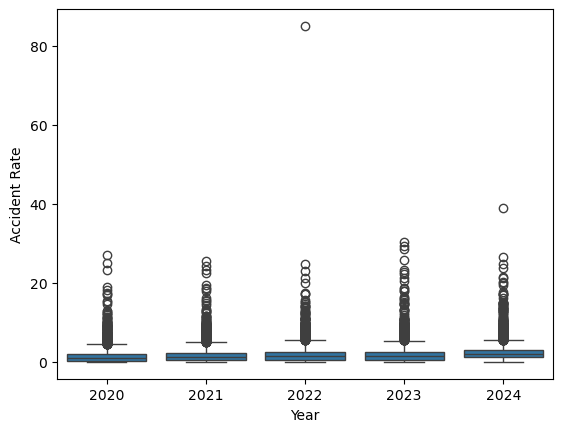

In [591]:
sns.boxplot(data=crashes_cities,x='Year',y='Accident Rate');

In [592]:
crashes_cities[crashes_cities['Accident Rate']>30]

,Year,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),CITY_CODE,Comune,Capoluogo di Provincia/Uts,Capoluogo di Regione,Superficie (Kmq),Popolazione residente,ROADACC,KILLED,INJURED,Accident Rate,Accident Density,Mortality Rate,Injury Rate,Fatalities per 100 crashes,Injuries per 100 crashes,Population Density
727,2022,1,1,1,1157,Moncenisio,0,0,4.5006,47,4,0,5,85.11,0.89,0.00,106.38,0.00,125.00,10.44
2310,2024,1,1,4,4006,Argentera,0,0,76.2592,77,3,1,5,38.96,0.04,12.99,64.94,33.33,166.67,1.01
35605,2023,1,3,97,97055,Morterone,0,0,13.6172,33,1,0,1,30.30,0.07,0.00,30.30,0.00,100.00,2.42


Inspecting the data we note that most of the outliers are made up of cities that have an extremely low population. This causes the Accident Rate to become very high, but such information doesn't carry any statistical meaning because even one single crash can make this quantity explode. Since we are interested in determining the best municipalities to invest into, it is clear that places with extremely low population cannot fit in this category. It is therefore reasonable to exclude these towns from our analysis. We shall therefore classify each municipality into 4 categories, following the usual ISTAT thresholds: Micro (population under 5000), Medium (between 5000 and 50.000), Macro (50.000 to 250.000), Metropolis (over 250.000).

In [593]:
conds = [crashes_cities['Popolazione residente']<5000, crashes_cities['Popolazione residente']<50000,
         crashes_cities['Popolazione residente']<250000, crashes_cities['Popolazione residente']>250000]
values = ['Micro','Medium','Macro','Metropolis']

crashes_cities['Category'] = np.select(conds,values,default='Non classifiable')

The idea of neglecting micro municipalities can be sustained by determining how many crashes are being neglected with respect to the entire country:

In [594]:
micro_crashes_pct = round((crashes_cities[crashes_cities['Category']=='Micro']['ROADACC'].sum()/crashes_cities['ROADACC'].sum())*100,2)
print(f'The percentage of crashes in micro municipalities is {micro_crashes_pct} %.')

The percentage of crashes in micro municipalities is 9.48 %.


Therefore, by restricting our analysis to non-micro municipalities, we are losing less than 10% of the total crashes. This allows us to avoid falling for outliers that are due to the great instability of the Accident Rate metric on very small towns:

In [595]:
crashes_cities[(crashes_cities['Accident Rate']>20) & (crashes_cities['Category']!='Micro')]

,Year,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),CITY_CODE,Comune,Capoluogo di Provincia/Uts,Capoluogo di Regione,Superficie (Kmq),Popolazione residente,...,KILLED,INJURED,Accident Rate,Accident Density,Mortality Rate,Injury Rate,Fatalities per 100 crashes,Injuries per 100 crashes,Population Density,Category


Now we can see what is the data distribution without considering the micro municipalities:

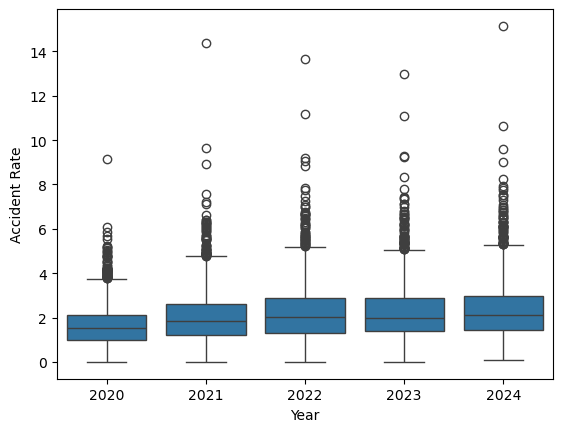

In [596]:
target_cities = crashes_cities[crashes_cities['Category']!='Micro']
sns.boxplot(data=target_cities,x='Year',y='Accident Rate');

In [597]:
target_cities[target_cities['Accident Rate']>10]

,Year,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),CITY_CODE,Comune,Capoluogo di Provincia/Uts,Capoluogo di Regione,Superficie (Kmq),Popolazione residente,...,KILLED,INJURED,Accident Rate,Accident Density,Mortality Rate,Injury Rate,Fatalities per 100 crashes,Injuries per 100 crashes,Population Density,Category
18463,2022,2,8,37,37005,Bentivoglio,0,0,51.1052,5714,...,2,103,11.20,1.25,0.35,18.03,3.12,160.94,111.81,Medium
18464,2023,2,8,37,37005,Bentivoglio,0,0,51.1052,5777,...,2,103,11.08,1.25,0.35,17.83,3.12,160.94,113.04,Medium
18465,2024,2,8,37,37005,Bentivoglio,0,0,51.1052,5821,...,0,89,10.65,1.21,0.00,15.29,0.00,143.55,113.90,Medium
20109,2021,3,9,46,46013,Forte dei Marmi,0,0,9.1867,6943,...,1,132,14.40,10.89,0.14,19.01,1.00,132.00,755.77,Medium
20110,2022,3,9,46,46013,Forte dei Marmi,0,0,9.1867,6879,...,0,120,13.66,10.23,0.00,17.44,0.00,127.66,748.80,Medium
20111,2023,3,9,46,46013,Forte dei Marmi,0,0,9.1867,6777,...,0,110,12.99,9.58,0.00,16.23,0.00,125.00,737.70,Medium
20112,2024,3,9,46,46013,Forte dei Marmi,0,0,9.1867,6666,...,0,128,15.15,10.99,0.00,19.20,0.00,126.73,725.61,Medium


We have no reason to eliminate the remaining extremes, that are instead exactly what we are looking for: municipalities the Accident Rates of which emerge from the background statistical distribution. These datapoints could in fact represent new investments possibilities.

We can briefly take a look at the outliers with respect to Accident Density:

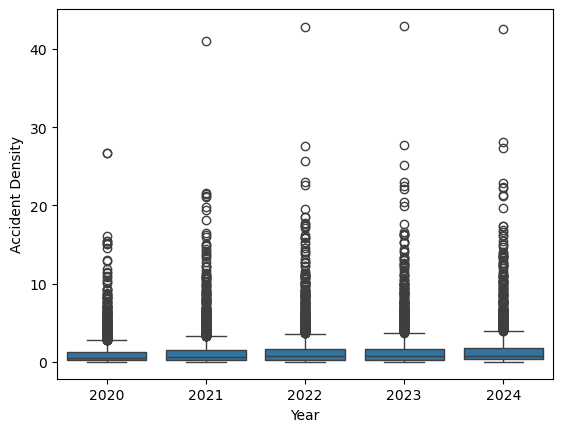

In [598]:
sns.boxplot(data=target_cities,x='Year',y='Accident Density');

In [599]:
target_cities[target_cities['Accident Density']>20]

,Year,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),CITY_CODE,Comune,Capoluogo di Provincia/Uts,Capoluogo di Regione,Superficie (Kmq),Popolazione residente,...,KILLED,INJURED,Accident Rate,Accident Density,Mortality Rate,Injury Rate,Fatalities per 100 crashes,Injuries per 100 crashes,Population Density,Category
1269,2021,1,1,1,1272,Torino,1,1,130.0547,848748,...,15,3918,3.29,21.48,0.02,4.62,0.54,140.28,6526.08,Metropolis
1270,2022,1,1,1,1272,Torino,1,1,130.0547,847398,...,31,4163,3.46,22.57,0.04,4.91,1.06,141.84,6515.70,Metropolis
1271,2023,1,1,1,1272,Torino,1,1,130.0547,851199,...,23,4131,3.43,22.44,0.03,4.85,0.79,141.57,6544.93,Metropolis
1272,2024,1,1,1,1272,Torino,1,1,129.9988,853196,...,16,4288,3.48,22.83,0.02,5.03,0.54,144.47,6563.11,Metropolis
8201,2021,1,3,15,15077,Cinisello Balsamo,0,0,12.7240,74391,...,2,350,3.63,21.22,0.03,4.70,0.74,129.63,5846.51,Macro
8203,2023,1,3,15,15077,Cinisello Balsamo,0,0,12.7240,74741,...,2,453,4.72,27.74,0.03,6.06,0.57,128.33,5874.02,Macro
8204,2024,1,3,15,15077,Cinisello Balsamo,0,0,12.7240,74702,...,4,461,4.66,27.35,0.05,6.17,1.15,132.47,5870.95,Macro
8228,2023,1,3,15,15086,Cormano,0,0,4.4733,20556,...,2,131,5.01,23.03,0.10,6.37,1.94,127.18,4595.27,Medium
8229,2024,1,3,15,15086,Cormano,0,0,4.4733,20744,...,1,175,6.07,28.17,0.05,8.44,0.79,138.89,4637.29,Medium
8235,2020,1,3,15,15093,Corsico,0,0,5.3556,34601,...,0,174,4.13,26.70,0.00,5.03,0.00,121.68,6460.71,Medium


These extreme values are completely reasonable and acceptable: in fact, they seem to favour highly populated cities and metropolitan areas that present a modest surface compared to the amount of activities (and therefore traffic) present.

### Top 5 cities by Accident Rate and Accident Density

We can start our analysis by determining the Top 5 municipalities by Accident Rate on the whole time period:

In [600]:
top5_rate = target_cities.groupby('Comune',as_index=False)['Accident Rate'].mean().sort_values('Accident Rate',ascending=False).head(5)
top5_rate

,Comune,Accident Rate
883,Forte dei Marmi,13.070
196,Bentivoglio,9.550
1093,Lignano Sabbiadoro,7.740
1947,Santa Margherita Ligure,7.718
197,Bergamo,6.974


We can follow the time trends of these 5 towns in the given period:

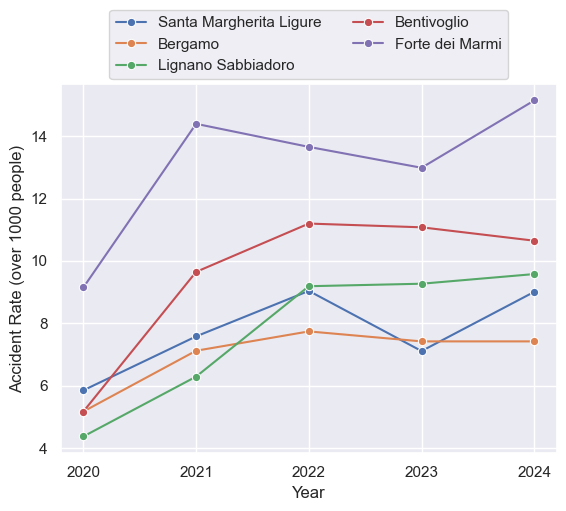

In [611]:
ax = sns.lineplot(data=target_cities[target_cities['Comune'].isin(top5_rate['Comune'])],
                  x='Year',y='Accident Rate',hue='Comune',marker='o');
ax.set_xticks(sorted(target_cities['Year'].unique()))
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=2);
plt.ylabel('Accident Rate (over 1000 people)');

Going further, we can determine the Top 5 municipalities by Accident Rate for each year:

In [602]:
for i in range(5):
    print(f'Top 5 for the year {2020+i} by Accident Rate: \n')
    print(target_cities[target_cities['Year']==
                        2020+i].sort_values('Accident Rate',ascending=False)[['Year','Comune','Accident Rate']].head(), '\n')

Top 5 for the year 2020 by Accident Rate: 

       Year                   Comune  Accident Rate
20108  2020          Forte dei Marmi           9.15
29210  2020            Porto Cesareo           6.10
6048   2020  Santa Margherita Ligure           5.85
5922   2020                  Lavagna           5.67
5456   2020                  Alassio           5.52 

Top 5 for the year 2021 by Accident Rate: 

       Year                   Comune  Accident Rate
20109  2021          Forte dei Marmi          14.40
18462  2021              Bentivoglio           9.65
5467   2021         Albissola Marina           8.94
6049   2021  Santa Margherita Ligure           7.58
5181   2021               Bordighera           7.21 

Top 5 for the year 2022 by Accident Rate: 

       Year                   Comune  Accident Rate
20110  2022          Forte dei Marmi          13.66
18463  2022              Bentivoglio          11.20
16981  2022       Lignano Sabbiadoro           9.19
6050   2022  Santa Margherita Li

We see that, while some towns are always present, some of them pop in or out of the ranking. We can select the names of all those that ended up in Top 5 at least once:

In [603]:
def top5_once(df,time,metric,label):
    return df.sort_values(metric,ascending=False).groupby(time)[label].head(5).unique().tolist()

In [604]:
top5_once_rate = top5_once(target_cities,'Year','Accident Rate','Comune')
top5_once_rate

['Forte dei Marmi',
 'Bentivoglio',
 'Lignano Sabbiadoro',
 'Assago',
 'Santa Margherita Ligure',
 'Albissola Marina',
 'Lavagna',
 'Bordighera',
 'Porto Cesareo',
 'Alassio']

We can also do the same for Accident Density:

In [605]:
top5_density = target_cities.groupby('Comune',as_index=False)['Accident Density'].mean().sort_values('Accident Density',
                                                                                                     ascending=False).head(5)
top5_density

,Comune,Accident Density
1254,Milano,39.224
652,Cinisello Balsamo,21.878
850,Firenze,21.540
2167,Torino,21.074
197,Bergamo,20.792


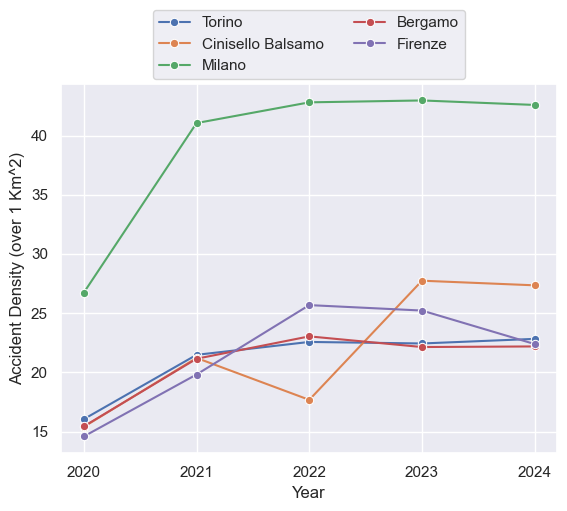

In [610]:
ax = sns.lineplot(data=target_cities[target_cities['Comune'].isin(top5_density['Comune'])],
                  x='Year',y='Accident Density',hue='Comune',marker='o');
ax.set_xticks(sorted(target_cities['Year'].unique()))
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=2);
plt.ylabel('Accident Density (over 1 Km^2)');

In [607]:
for i in range(5):
    print(f'Top 5 for the year {2020+i} by Accident Density: \n')
    print(target_cities[target_cities['Year']==
                        2020+i].sort_values('Accident Density',ascending=False)[['Year','Comune','Accident Density']].head(5), '\n')

Top 5 for the year 2020 by Accident Density: 

      Year             Comune  Accident Density
8370  2020             Milano             26.73
8235  2020            Corsico             26.70
1268  2020             Torino             16.05
8788  2020            Bergamo             15.44
8200  2020  Cinisello Balsamo             15.40 

Top 5 for the year 2021 by Accident Density: 

      Year              Comune  Accident Density
8371  2021              Milano             41.05
8570  2021  Sesto San Giovanni             21.63
1269  2021              Torino             21.48
8201  2021   Cinisello Balsamo             21.22
8789  2021             Bergamo             21.15 

Top 5 for the year 2022 by Accident Density: 

       Year              Comune  Accident Density
8372   2022              Milano             42.80
8571   2022  Sesto San Giovanni             27.61
20375  2022             Firenze             25.68
8790   2022             Bergamo             23.04
1270   2022            

In [608]:
top5_once_density = top5_once(target_cities,'Year','Accident Density','Comune')
top5_once_density

['Milano',
 'Cormano',
 'Cinisello Balsamo',
 'Sesto San Giovanni',
 'Corsico',
 'Firenze',
 'Bergamo',
 'Torino']